In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
# Прочитайте данные (переменную назовите 'df')
df = pd.read_csv('data.csv')

# Вывести несколько первых строк таблицы данных
print(df.head())

         Дата  Склад Контрагент Номенклатура  Количество
0  2018-01-04      1  address_0    product_0           4
1  2018-01-04      1  address_0    product_1           4
2  2018-01-04      1  address_0    product_2           5
3  2018-01-04      1  address_0    product_3          10
4  2018-01-04      1  address_0    product_4           2


In [15]:
print(df.dtypes)

Дата            datetime64[ns]
Склад                    int64
Контрагент              object
Номенклатура            object
Количество               int64
dtype: object


Проверяем формат столбцов

In [16]:
df['Дата'] = pd.to_datetime(df['Дата'])
print(df.dtypes)

Дата            datetime64[ns]
Склад                    int64
Контрагент              object
Номенклатура            object
Количество               int64
dtype: object


Сразу переведем столбец "Дата" в правильный формат

Сгруппируйте данные по дате, посчитайте количество продаж

In [18]:
grouped_df = df.groupby('Дата')['Количество'].sum()

Вывести несколько первых строк сгруппированных данных

In [19]:
grouped_df

Дата
2018-01-04    3734
2018-01-05    3643
2018-01-06    3193
2018-01-07    3298
2018-01-09    4055
              ... 
2018-08-26    5302
2018-08-28    5983
2018-08-29    4969
2018-08-30    4648
2018-08-31    4570
Name: Количество, Length: 205, dtype: int64

In [23]:
print(grouped_df.head())

Дата
2018-01-04    3734
2018-01-05    3643
2018-01-06    3193
2018-01-07    3298
2018-01-09    4055
Name: Количество, dtype: int64


Нарисуйте график продаж у `grouped_df`

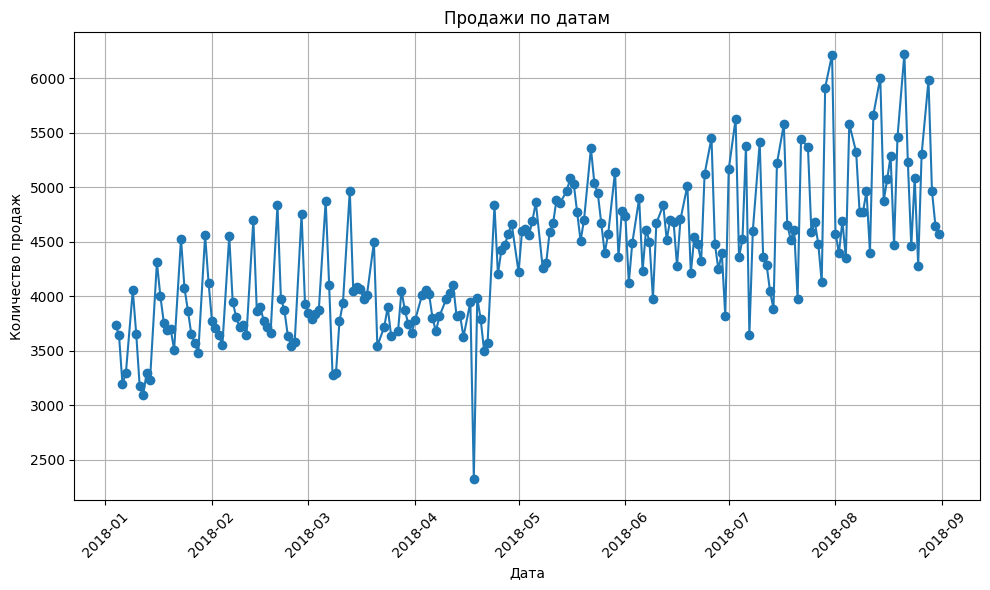

In [24]:
plt.figure(figsize=(10, 6))  
plt.plot(grouped_df, marker='o', linestyle='-') 
plt.title('Продажи по датам')  
plt.xlabel('Дата')  
plt.ylabel('Количество продаж') 
plt.xticks(rotation=45)  
plt.grid(True) 
plt.tight_layout() 
plt.show()

Опишите что вы видите на графике. Ваша задача - максимально описать график

In [ ]:
#данный график позволяет наглядно оценить динамику продаж во времени, определить максимальные и минимальные значения, увидеть резкие изменения и понять общую тенденцию изменения количества продаж.

Найдите строку, у которой максимальный выброс по количеству продаж (нужно найти выброс у `df`)

In [25]:
max_sales_row = df[df['Количество'] == df['Количество'].max()]
print(max_sales_row)

             Дата  Склад   Контрагент Номенклатура  Количество
218822 2018-06-28      1  address_208    product_0         200


Найдите топовый товар по продажам по средам за июнь, июль, август у 3 склада

In [27]:
df = df[df['Склад'] == 3]
df = df[df['Дата'].dt.dayofweek == 2]
df = df[df['Дата'].dt.month.isin([6, 7, 8])]
grouped = df.groupby('Номенклатура')['Количество'].sum()
top_product = grouped.idxmax()
print(f"Топовый товар по продажам по средам за июнь, июль, август у 3 склада: {top_product}")


Топовый товар по продажам по средам за июнь, июль, август у 3 склада: product_1


Скачайте данные по погоде с https://rp5.ru/Архив_погоды_в_Астане (скачайте исходные данные, и далее преобразуйте так, чтобы мы имели Дату и Среднюю температуру за день), объедините таблицу температуры с `grouped_df`, и нарисуйте график `y=['Количество продаж', 'T']`, где Т это температура. А также отдельно график температуры.

In [33]:
pip install xlrd

Note: you may need to restart the kernel to use updated packages.


In [34]:
import pandas as pd

df_weather = pd.read_excel("weather.xls")
print(df_weather.head())

        Дата     T
0 2018-08-31   9.6
1 2018-08-31  11.3
2 2018-08-31  12.3
3 2018-08-31  13.2
4 2018-08-31  12.5


In [36]:
df_weather['Дата'] = pd.to_datetime(df_weather['Дата'])
merged_df = pd.merge(grouped_df, df_weather, on='Дата')
merged_df


,Дата,Количество,T
0,2018-01-04,3734,-17.2
1,2018-01-04,3734,-14.5
2,2018-01-04,3734,-9.6
3,2018-01-04,3734,-12.3
4,2018-01-04,3734,-12.6
...,...,...,...
1634,2018-08-31,4570,13.2
1635,2018-08-31,4570,12.5
1636,2018-08-31,4570,10.3
1637,2018-08-31,4570,10.8


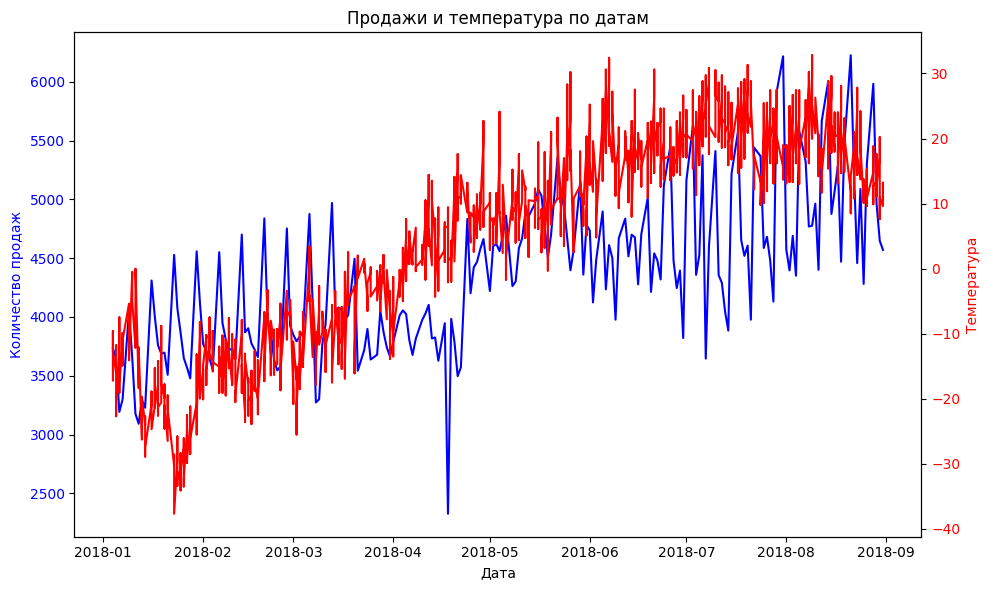

In [37]:
fig, ax1 = plt.subplots(figsize=(10, 6))
ax1.plot(merged_df['Дата'], merged_df['Количество'], label='Количество продаж', color='b')
ax1.set_xlabel('Дата')
ax1.set_ylabel('Количество продаж', color='b')
ax1.tick_params(axis='y', labelcolor='b')

ax2 = ax1.twinx()
ax2.plot(merged_df['Дата'], merged_df['T'], label='Температура', color='r')
ax2.set_ylabel('Температура', color='r')
ax2.tick_params(axis='y', labelcolor='r')

plt.title('Продажи и температура по датам')
fig.tight_layout()
plt.show()

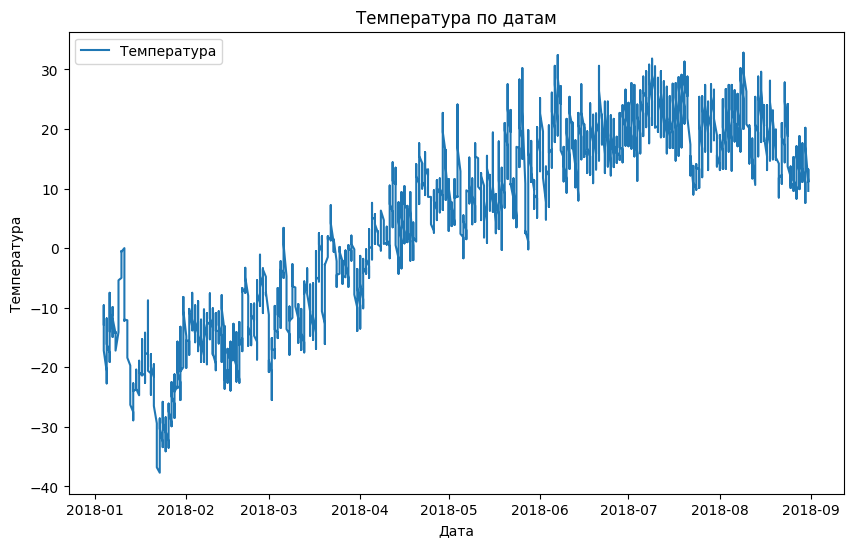

In [38]:
plt.figure(figsize=(10, 6))
plt.plot(df_weather['Дата'], df_weather['T'], label='Температура')
plt.title('Температура по датам')
plt.xlabel('Дата')
plt.ylabel('Температура')
plt.legend()
plt.show()